In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
from imblearn.over_sampling import SMOTE

In [27]:
df = pd.read_csv('../dataset/dataset_kematangan_tapai.csv')

df.dropna(inplace=True)
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   percobaan          600 non-null    int64  
 1   jam                600 non-null    int64  
 2   suhu               600 non-null    float64
 3   kelembaban         600 non-null    float64
 4   kadar_gas          600 non-null    float64
 5   status_kematangan  600 non-null    str    
dtypes: float64(3), int64(2), str(1)
memory usage: 28.3 KB
None


,percobaan,jam,suhu,kelembaban,kadar_gas,status_kematangan
0,1,1,28.73,78.77,0.02,belum matang
1,1,2,28.51,78.62,0.01,belum matang
2,1,3,28.33,78.22,0.01,belum matang
3,1,4,29.20,78.46,0.01,belum matang
4,1,5,28.42,78.65,0.00,belum matang


/var/folders/c8/w5653zh95fv3vzdrz0pxdvc80000gn/T/ipykernel_875/1710659568.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(counts, palette=palette.values())


<Axes: xlabel='status_kematangan', ylabel='count'>

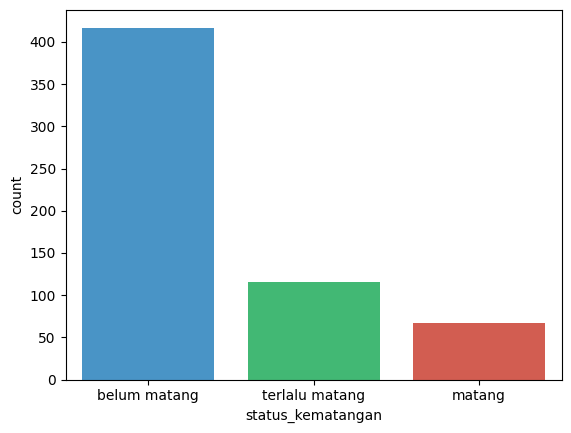

In [28]:
counts = df['status_kematangan'].value_counts()
palette = {'belum matang': '#3498db', 'matang': '#2ecc71', 'terlalu matang': '#e74c3c'}

sns.barplot(counts, palette=palette.values())

In [29]:
x = df[['suhu', 'kelembaban', 'kadar_gas', 'jam']]
y = df['status_kematangan']

sample = SMOTE()
transformed_x, transformed_y = sample.fit_resample(x, y)

print("Old data: ", y.value_counts())
print("New data: ", transformed_y.value_counts())

Old data:  status_kematangan
belum matang      417
terlalu matang    116
matang             67
Name: count, dtype: int64
New data:  status_kematangan
belum matang      417
matang            417
terlalu matang    417
Name: count, dtype: int64


In [30]:
transformed_df = pd.concat([transformed_x, transformed_y], axis=1)
print(transformed_df.info())
transformed_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1251 entries, 0 to 1250
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   suhu               1251 non-null   float64
 1   kelembaban         1251 non-null   float64
 2   kadar_gas          1251 non-null   float64
 3   jam                1251 non-null   int64  
 4   status_kematangan  1251 non-null   str    
dtypes: float64(3), int64(1), str(1)
memory usage: 49.0 KB
None


,suhu,kelembaban,kadar_gas,jam,status_kematangan
0,28.73,78.77,0.02,1,belum matang
1,28.51,78.62,0.01,2,belum matang
2,28.33,78.22,0.01,3,belum matang
3,29.20,78.46,0.01,4,belum matang
4,28.42,78.65,0.00,5,belum matang


/var/folders/c8/w5653zh95fv3vzdrz0pxdvc80000gn/T/ipykernel_875/618446790.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(counts, palette=palette.values())


<Axes: xlabel='status_kematangan', ylabel='count'>

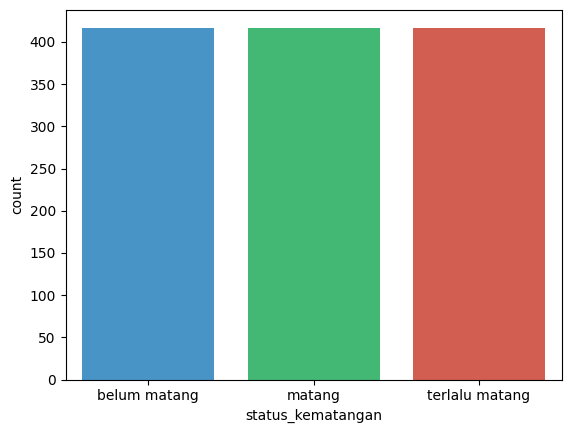

In [32]:
counts = transformed_df['status_kematangan'].value_counts()
sns.barplot(counts, palette=palette.values())

In [31]:
transformed_df.to_csv('../dataset/dataset_kematangan_tapai_cleaned.csv')